# Ablation Study
- do it with and without acceleration for different context lengths

In [1]:
## Load necessary library files ##

import sys
sys.path.append('..')
from sharp.utils import get_sequence, DatasetConverter
from sharp.model.model import Model

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch import from_numpy as tnsr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pickle 

In [2]:
## select device ##
device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [3]:
total_samples, n_community, n_members = 5000000, 2, 3
total_layers, head_layers, short_term_memory = 3, 3, 4

context_depths = [2, 4, 6, 8]
context_length = [7, 13, 19, 25]
vocab_size = n_community*n_members + 1


In [4]:
reps = 10
res = []
repititions = []
context = []
samples_seen = []

for rep in tqdm(range(reps)):
    for id, context_depth in enumerate(context_depths):
        model = Model(
            total_layers = total_layers,
            num_layers_prediction_head = head_layers,

            # ---- Layer sizes ----
            vocab_size = vocab_size,                  # layer 0 input dimension
            hidden_sizes = [100, 100, 100],    # H0, H1
            embedding_dim = 30,

            # ---- Learning rates per layer ----
            lr_layers = 1e-4,   

            # ---- Optimizer type (user can choose) ----
            optimizer_class = torch.optim.Adam,
            optimizer_kwargs = {
                "weight_decay": 1e-12
            },

            # ---- Sleep hyperparameters ----
            short_term_memory = short_term_memory,
            context_tag_buffer_size=100,
            # ---- Misc ----
            recon_threshold = 1e-3,
            device = device
        )

        data = get_sequence(total_samples, n_community, n_members, context_depth=context_depth, train_percent=1.0)
        dataset = DatasetConverter(data, short_term_memory=short_term_memory)
        loader = DataLoader(dataset, batch_size=1, shuffle=False)
        
        ii = 0 
        h_ = None
        correct_ring = np.zeros(1000)
        for x, y in loader:
            x = x.to(device).long()
            y = y.to(device).long()
            logits, loss, recon_loss, h_ = model.wake_step(x, y, h_)


            with torch.no_grad():
                ii += 1
                pred_tok = logits.argmax(dim=-1)
                correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()
                
                if ii%1000 == 0:
                    acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                    res.append(acc)
                    samples_seen.append(ii)
                    repititions.append(rep)
                    context.append(id)


            if ii%20000==0:
                model.sleep(total_steps=64)


df = pd.DataFrame()
df['reps'] = repititions
df['samples seen'] = samples_seen
df['context required'] = context
df['Accuracy'] = res

with open('../pickle_files/ablation_with_acceleration.pickle', 'wb') as f:
    pickle.dump(df, f)

100%|██████████| 10/10 [75:56:35<00:00, 27339.51s/it]  


In [ ]:
reps = 10
res = []
repititions = []
context = []
samples_seen = []

for rep in tqdm(range(reps)):
    for id, context_depth in enumerate(context_depths):
        model = Model(
            total_layers = total_layers,
            num_layers_prediction_head = head_layers,

            # ---- Layer sizes ----
            vocab_size = vocab_size,                  # layer 0 input dimension
            hidden_sizes = [100, 100, 100],    # H0, H1
            embedding_dim = 30,

            # ---- Learning rates per layer ----
            lr_layers = 1e-4,   

            # ---- Optimizer type (user can choose) ----
            optimizer_class = torch.optim.Adam,
            optimizer_kwargs = {
                "weight_decay": 1e-12
            },

            # ---- Sleep hyperparameters ----
            short_term_memory = short_term_memory,
            context_tag_buffer_size=100,
            # ---- Misc ----
            recon_threshold = 1e-3,
            accelerate = 1,
            device = device
        )

        data = get_sequence(total_samples, n_community, n_members, context_depth=context_depth, train_percent=1.0)
        dataset = DatasetConverter(data, short_term_memory=short_term_memory)
        loader = DataLoader(dataset, batch_size=1, shuffle=False)
        
        ii = 0 
        h_ = None
        correct_ring = np.zeros(1000)
        for x, y in loader:
            x = x.to(device).long()
            y = y.to(device).long()
            logits, loss, recon_loss, h_ = model.wake_step(x, y, h_)


            with torch.no_grad():
                ii += 1
                pred_tok = logits.argmax(dim=-1)
                correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()
                
                if ii%1000 == 0:
                    acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                    res.append(acc)
                    samples_seen.append(ii)
                    repititions.append(rep)
                    context.append(id)


            if ii%20000==0:
                model.sleep(total_steps=16)


df = pd.DataFrame()
df['reps'] = repititions
df['samples seen'] = samples_seen
df['context required'] = context
df['Accuracy'] = res

with open('../pickle_files/ablation_without_acceleration.pickle', 'wb') as f:
    pickle.dump(df, f)

100%|██████████| 10/10 [99:56:19<00:00, 35978.00s/it]   


In [4]:
reps = 10
res = []
repititions = []
context = []
samples_seen = []

for rep in tqdm(range(reps)):
    for id, context_depth in enumerate(context_depths):
        model = Model(
            total_layers = total_layers,
            num_layers_prediction_head = head_layers,

            # ---- Layer sizes ----
            vocab_size = vocab_size,                  # layer 0 input dimension
            hidden_sizes = [100, 100, 100],    # H0, H1
            embedding_dim = 30,

            # ---- Learning rates per layer ----
            lr_layers = 1e-4,   

            # ---- Optimizer type (user can choose) ----
            optimizer_class = torch.optim.Adam,
            optimizer_kwargs = {
                "weight_decay": 1e-12
            },

            # ---- Sleep hyperparameters ----
            short_term_memory = short_term_memory,
            context_tag_buffer_size=100,
            # ---- Misc ----
            recon_threshold = 1e-3,
            accelerate = 2,
            device = device
        )

        data = get_sequence(total_samples, n_community, n_members, context_depth=context_depth, train_percent=1.0)
        dataset = DatasetConverter(data, short_term_memory=short_term_memory)
        loader = DataLoader(dataset, batch_size=1, shuffle=False)
        
        ii = 0 
        h_ = None
        correct_ring = np.zeros(1000)
        for x, y in loader:
            x = x.to(device).long()
            y = y.to(device).long()
            logits, loss, recon_loss, h_ = model.wake_step(x, y, h_)


            with torch.no_grad():
                ii += 1
                pred_tok = logits.argmax(dim=-1)
                correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()
                
                if ii%1000 == 0:
                    acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                    res.append(acc)
                    samples_seen.append(ii)
                    repititions.append(rep)
                    context.append(id)


            if ii%20000==0:
                model.sleep_step(total_steps=16)


df = pd.DataFrame()
df['reps'] = repititions
df['samples seen'] = samples_seen
df['context required'] = context
df['Accuracy'] = res

with open('../pickle_files/ablation_2X_acceleration.pickle', 'wb') as f:
    pickle.dump(df, f)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [72:29:12<00:00, 26095.22s/it]  


In [5]:
reps = 10
res = []
repititions = []
context = []
samples_seen = []

for rep in tqdm(range(reps)):
    for id, context_depth in enumerate(context_depths):
        model = Model(
            total_layers = total_layers,
            num_layers_prediction_head = head_layers,

            # ---- Layer sizes ----
            vocab_size = vocab_size,                  # layer 0 input dimension
            hidden_sizes = [100, 100, 100],    # H0, H1
            embedding_dim = 30,

            # ---- Learning rates per layer ----
            lr_layers = 1e-4,   

            # ---- Optimizer type (user can choose) ----
            optimizer_class = torch.optim.Adam,
            optimizer_kwargs = {
                "weight_decay": 1e-12
            },

            # ---- Sleep hyperparameters ----
            short_term_memory = short_term_memory,
            context_tag_buffer_size=100,
            # ---- Misc ----
            recon_threshold = 1e-3,
            accelerate = 6,
            device = device
        )

        data = get_sequence(total_samples, n_community, n_members, context_depth=context_depth, train_percent=1.0)
        dataset = DatasetConverter(data, short_term_memory=short_term_memory)
        loader = DataLoader(dataset, batch_size=1, shuffle=False)
        
        ii = 0 
        h_ = None
        correct_ring = np.zeros(1000)
        for x, y in loader:
            x = x.to(device).long()
            y = y.to(device).long()
            logits, loss, recon_loss, h_ = model.wake_step(x, y, h_)


            with torch.no_grad():
                ii += 1
                pred_tok = logits.argmax(dim=-1)
                correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()
                
                if ii%1000 == 0:
                    acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                    res.append(acc)
                    samples_seen.append(ii)
                    repititions.append(rep)
                    context.append(id)


            if ii%20000==0:
                model.sleep_step(total_steps=16)


df = pd.DataFrame()
df['reps'] = repititions
df['samples seen'] = samples_seen
df['context required'] = context
df['Accuracy'] = res

with open('../pickle_files/ablation_6X_acceleration.pickle', 'wb') as f:
    pickle.dump(df, f)

100%|██████████| 10/10 [69:12:57<00:00, 24917.70s/it]  


In [ ]:
reps = 10
res = []
repititions = []
context = []
samples_seen = []

for rep in tqdm(range(reps)):
    for id, context_depth in enumerate(context_depths):
        model = Model(
            total_layers = total_layers,
            num_layers_prediction_head = head_layers,

            # ---- Layer sizes ----
            vocab_size = vocab_size,                  # layer 0 input dimension
            hidden_sizes = [100, 100, 100],    # H0, H1
            embedding_dim = 30,

            # ---- Learning rates per layer ----
            lr_layers = 1e-4,   

            # ---- Optimizer type (user can choose) ----
            optimizer_class = torch.optim.Adam,
            optimizer_kwargs = {
                "weight_decay": 1e-12
            },

            # ---- Sleep hyperparameters ----
            short_term_memory = short_term_memory,
            context_tag_buffer_size=100,
            # ---- Misc ----
            recon_threshold = 1e-3,
            bad_init=True,
            device = device
        )

        data = get_sequence(total_samples, n_community, n_members, context_depth=context_depth, train_percent=1.0)
        dataset = DatasetConverter(data, short_term_memory=short_term_memory)
        loader = DataLoader(dataset, batch_size=1, shuffle=False)
        
        ii = 0 
        h_ = None
        correct_ring = np.zeros(1000)
        for x, y in loader:
            x = x.to(device).long()
            y = y.to(device).long()
            logits, loss, recon_loss, h_ = model.wake_step(x, y, h_)


            with torch.no_grad():
                ii += 1
                pred_tok = logits.argmax(dim=-1)
                correct_ring[ii % 1000] = (pred_tok[0] == y[0, 0]).item()
                
                if ii%1000 == 0:
                    acc = np.sum(correct_ring) / (1000 if ii >= 1000 else ii)
                    res.append(acc)
                    samples_seen.append(ii)
                    repititions.append(rep)
                    context.append(id)


df = pd.DataFrame()
df['reps'] = repititions
df['samples seen'] = samples_seen
df['context required'] = context
df['Accuracy'] = res

with open('../pickle_files/ablation_with_acceleration_no_sleep.pickle', 'wb') as f:
    pickle.dump(df, f)

Loaded 1x
Loaded 2x
Loaded 4x
Loaded 4X (no sleep)
Loaded 6x
Skipping 8x (not ready yet)
Loaded vanilla RNN


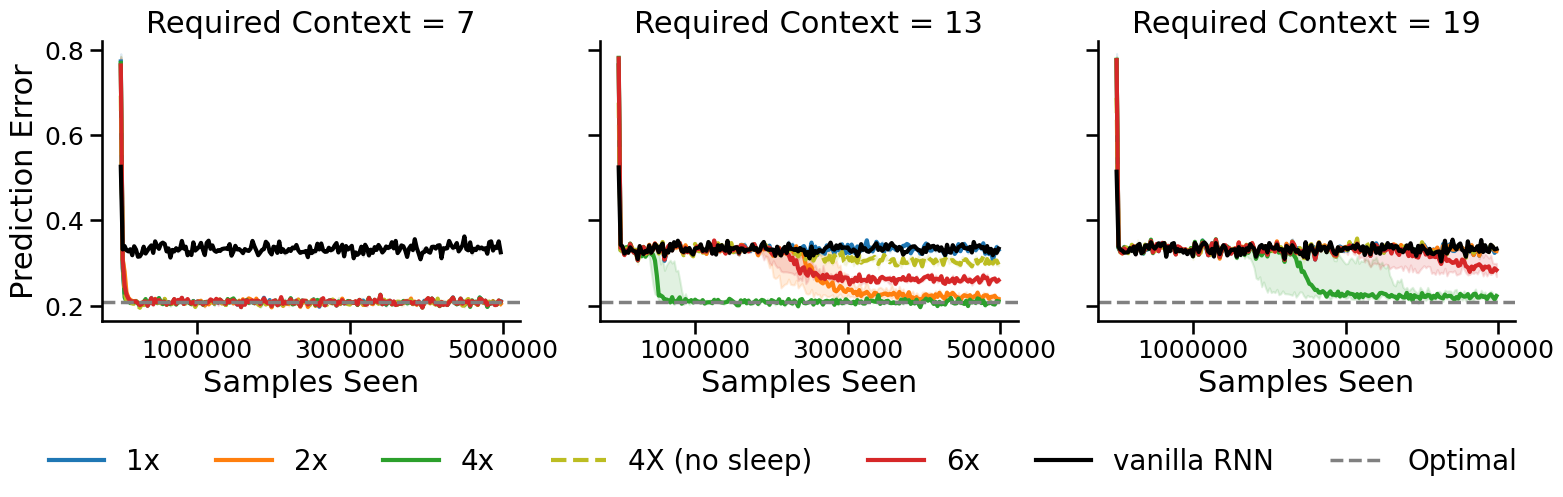

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

sns.set_context("talk")

# ===================== SETTINGS =====================
fontsize = 22
downsample_every = 25

context_map = {
    0: 7,
    1: 13,
    2: 19,
    3: 25
}

selected_contexts = [7, 13, 19]

pickle_files = {
    "1x": "../pickle_files/ablation_without_acceleration.pickle",
    "2x": "../pickle_files/ablation_2X_acceleration.pickle",
    "4x": "../pickle_files/ablation_with_acceleration.pickle",
    "4X (no sleep)": "../pickle_files/ablation_with_acceleration_no_sleep.pickle",
    "6x": "../pickle_files/ablation_6X_acceleration.pickle",
    "8x": "../pickle_files/ablation_8X_acceleration.pickle",
    "vanilla RNN": "../pickle_files/naive_rnn_bptt4_ablation.pickle",
}

colors = {
    "1x": "tab:blue",
    "2x": "tab:orange",
    "4x": "tab:green",
    "4X (no sleep)": "tab:olive",
    "6x": "tab:red",
    "8x": "tab:purple",
    "vanilla RNN": "black",
}

linestyles = {
    "1x": "-",
    "2x": "-",
    "4x": "-",
    "4X (no sleep)": "--",
    "6x": "-",
    "8x": "-",
    "vanilla RNN": "-",
}

alphas = {
    "1x": 0.14,
    "2x": 0.14,
    "4x": 0.14,
    "4X (no sleep)": 0.10,
    "6x": 0.14,
    "8x": 0.14,
    "vanilla RNN": 0.10,
}

# ===================== LOAD =====================
dfs = {}
for rate, path in pickle_files.items():
    if os.path.exists(path):
        with open(path, "rb") as f:
            dfs[rate] = pickle.load(f)
        print(f"Loaded {rate}")
    else:
        print(f"Skipping {rate} (not ready yet)")

# ===================== PREP =====================
for k in dfs:
    dfs[k] = dfs[k].copy()

    # support both naming conventions
    if "samples seen" in dfs[k].columns:
        dfs[k]["samples_seen"] = dfs[k]["samples seen"]
    elif "samples_seen" not in dfs[k].columns:
        raise KeyError(f"'samples seen' column missing for {k}")

    if "context required" in dfs[k].columns:
        dfs[k]["context_id"] = dfs[k]["context required"]
    elif "context_id" not in dfs[k].columns:
        raise KeyError(f"'context required' column missing for {k}")

    dfs[k]["context_length"] = dfs[k]["context_id"].map(context_map)
    dfs[k]["Error"] = 1.0 - dfs[k]["Accuracy"]

# ===================== HELPER =====================
def compute_stats(df):
    g = df.groupby("samples_seen")["Error"]
    x = g.median().index.values
    med = g.median().values
    q25 = g.quantile(0.25).values
    q75 = g.quantile(0.75).values

    idx = np.arange(0, len(x), downsample_every)
    return x[idx], med[idx], q25[idx], q75[idx]

# ===================== PLOT =====================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

rate_order = ["1x", "2x", "4x", "4X (no sleep)", "6x", "8x", "vanilla RNN"]
loaded_rate_order = [r for r in rate_order if r in dfs]

for ax, ctx in zip(axes, selected_contexts):
    for rate in loaded_rate_order:
        sub = dfs[rate][dfs[rate]["context_length"] == ctx]
        if len(sub) == 0:
            continue

        x, med, q25, q75 = compute_stats(sub)

        ax.plot(
            x, med,
            linewidth=3,
            color=colors[rate],
            linestyle=linestyles[rate],
            label=rate
        )
        ax.fill_between(
            x, q25, q75,
            color=colors[rate],
            alpha=alphas[rate]
        )

    chance_acc = 0.7917
    chance_err = 1.0 - chance_acc
    ax.axhline(
        chance_err,
        linestyle="--",
        color="gray",
        linewidth=2.5,
        label="Optimal"
    )

    ax.set_title(f"Required Context = {ctx}", fontsize=fontsize)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(labelsize=fontsize - 4)
    ax.ticklabel_format(style='plain', axis='x')
    ax.set_xticks([1_000_000, 3_000_000, 5_000_000])

axes[0].set_ylabel("Prediction Error", fontsize=fontsize)
for ax in axes:
    ax.set_xlabel("Samples Seen", fontsize=fontsize)

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()
seen = set()
uniq_handles, uniq_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        uniq_handles.append(h)
        uniq_labels.append(l)
        seen.add(l)

fig.legend(
    uniq_handles, uniq_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=min(len(uniq_labels), 8),
    frameon=False,
    fontsize=fontsize - 2
)

os.makedirs("../plots", exist_ok=True)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("../plots/ablation_acceleration_rate.pdf", bbox_inches="tight")
plt.show()